## Bibliometric Network Analysis & Topic Modelling


Welcome to this Jupyter notebook on "Bibliometric Analysis and Topic Modelling."

In the rapidly evolving landscape of academic research, bibliometric data serves as a treasure trove of insights. By analyzing the relationships between various metadata components like authors, titles, and citations, we can unveil patterns, trends, and dominant themes that shape the contours of scientific thought.

Leveraging the expansive bibliometric dataset from Web of Science, this notebook harnesses the power of the Metaknowledge package to delve deep into the intricacies of co-authorship networks and to discern the dominant academic topics through LDA topic modelling. Our analysis is guided by three primary questions:

Who among the top authors frequently collaborate, making them dominant co-authors?
How does the co-authorship network manifest, and what can we deduce from its structure?
Which themes or topics resonate most in the academic papers under our lens?
As we navigate through the sections of this notebook, we'll employ a systematic approach, starting with data preprocessing, followed by network construction and visualization, and culminating in topic modelling. Along the way, visualizations will enrich our understanding and help crystallize the insights drawn from the data.

Whether you're a bibliometrics enthusiast, a data scientist, or just someone curious about the dynamics of academic research, this notebook aims to provide a comprehensive exploration, replete with insights and visual narratives. So, let's embark on this analytical journey!





In [55]:
!pip install pyLDAvis


In [56]:
import os
import pandas as pd
import numpy as np
import seaborn as sns



import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
import spacy
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import ldamodel
from gensim.models import CoherenceModel 
import re
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt


from pprint import pprint
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [57]:
#!pip install metaknowledge 

In [58]:
#!pip3 install metaknowledge


In [59]:
#!pip3 install python-louvain


In [60]:
import networkx as nx
import metaknowledge as mk
import community


In [61]:
# Importing the information science and bibliometrics dataset
coll_rec = mk.RecordCollection("C:/Users/User/Documents/Project Drills/Bibliometric Analysis/raw_data/imetrics")



In [62]:
len(coll_rec)

8140

In [63]:
coll_rec

<metaknowledge.RecordCollection object files-from-C:\Users\User\Documents\Project Drills\Bibliometric Analysis\raw_data\imetrics>

The data we have is stored in a RecordCollection object. To visualize its contents, it's essential to convert it into a dataframe. 
This conversion can be accomplished through two different methods:
1. Utilizing the Pandas library, or
2. Employing the makeDict() function provided by the Metaknowledge package.


In [64]:
# Saving the dataset as a csv file
coll_rec.writeCSV("biblio_records.csv")
# Reading in the data as a Pandas dataframe
df = pd.read_csv("biblio_records.csv")
df.head(10)

,id,TI,AF,CR,ID,DI,PT,AU,SO,LA,...,CL,SP,HO,SI,CA,PM,num-Authors,num-Male,num-Female,num-Unknown
0,WOS:A1995QW78100003,COMPUTER-AIDED CLUSTERING OF CITATION NETWORKS...,"DUPLENKO, YK|BURCHINSKY, SG","OKUBO Y, 1992, SCIENTOMETRICS, V25, P321, DOI ...",SCIENCE,10.1007/BF02017644,J,"DUPLENKO, YK|BURCHINSKY, SG",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,2
1,WOS:000299088900012,Performance evaluation of research universitie...,"Li, Feng|Yi, Yong|Guo, Xiaolong|Qi, Wei","Enserink M, 2007, SCIENCE, V317, P1026, DOI 10...",INDEX|SCIENCE|IMPACT|QUANTITY|JOURNALS|RANKING...,10.1007/s11192-011-0544-1,J,"Li, F|Yi, Y|Guo, XL|Qi, W",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0,3
2,WOS:000251377600025,Radio Frequency Identification handbook for li...,"Orme, Marianne|Robkin, Shai","Haley C. K., 2007, RADIO FREQUENCY IDEN",NaN,10.1002/asi.20723,J,"Orme, M|Robkin, S",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,1,1
3,WOS:000176415300008,The sources used by bibliometrics-scientometri...,"Peritz, BC|Bar-Ilan, J","Al-Sabbagh I. A., 1987, THESIS FLORIDA STATE|F...",SCIENTIFIC JOURNALS|CITATION ANALYSIS|SELF-CIT...,10.1023/A:1016018013096,J,"Peritz, BC|Bar-Ilan, J",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,2
4,WOS:000173320900005,Cognitive and task influences on Web searching...,"Kim, KS|Allen, B","Allen B, 1997, INFORMATION SEEKING IN CONTEXT,...",WORLD-WIDE-WEB|INFORMATION-SEEKING|LEARNING ST...,10.1002/asi.10014,J,"Kim, KS|Allen, B",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,2
5,WOS:000257168200005,Components of abstracts: Logical structure of ...,"Sauperl, Alenka|Klasinc, Janko|Luzar, Simona","*AM ASS PHARM SCI, 2002, PHARM DEV TECHN|Water...",SCIENCE,10.1002/asi.20858,J,"Sauperl, A|Klasinc, J|Luzar, S",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2,1
6,WOS:000310964500020,In public peer review of submitted manuscripts...,"Bornmann, Lutz|Herich, Hanna|Joos, Hanna|Danie...",American Association for the Advancement of Sc...,PREDICTIVE-VALIDITY|AGREEMENT|QUALITY|MISCONDU...,10.1007/s11192-012-0731-8,J,"Bornmann, L|Herich, H|Joos, H|Daniel, HD",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,4,1,2,1
7,WOS:000368338400023,The missing link: Information behavior researc...,"Lueg, Christopher P.","Anderson T. K., 2001, INFORM RES, V6, P169|Baw...",RELEVANCE|SCIENCE,10.1002/asi.23441,J,"Lueg, CP",JOURNAL OF THE ASSOCIATION FOR INFORMATION SCI...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
8,WOS:000292210200007,Weighted indices for evaluating the quality of...,"Abbas, Ash Mohammad","ABBAS AM, 2011, ARXIV11012985V1CSDL|ABBAS AM, ...",H-INDEX|PUBLICATION|CREDIT|OUTPUT,10.1007/s11192-011-0389-7,J,"Abbas, AM",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
9,WOS:000252821600010,Experiments with transitive dictionary transla...,"Lehtokangas, Raija|Keskustalo, Heikki|Jarvelin...","Efthimiadis EN, 1996, ANNU REV INFORM SCI, V31...",LANGUAGE INFORMATION-RETRIEVAL|CLIR,10.1002/asi.20762,J,"Lehtokangas, R|Keskustalo, H|Jarvelin, K",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1,2


In [65]:
# Saving the data as a dataframe using mk's makeDict()
df2 = pd.DataFrame(coll_rec.makeDict())
df2.head(10)

,PT,AU,AF,TI,SO,LA,DT,ID,AB,RP,...,CL,SP,HO,SI,CA,PM,num-Authors,num-Male,num-Female,num-Unknown
0,J,"[DUPLENKO, YK, BURCHINSKY, SG]","[DUPLENKO, YK, BURCHINSKY, SG]",COMPUTER-AIDED CLUSTERING OF CITATION NETWORKS...,SCIENTOMETRICS,English,Article,[SCIENCE],The use of the cluster analysis in scientometr...,"DUPLENKO, YK (reprint author), UKRAINE ACAD ME...",...,None,None,None,None,None,None,2,0,0,2
1,J,"[Li, F, Yi, Y, Guo, XL, Qi, W]","[Li, Feng, Yi, Yong, Guo, Xiaolong, Qi, Wei]",Performance evaluation of research universitie...,SCIENTOMETRICS,English,Article,"[INDEX, SCIENCE, IMPACT, QUANTITY, JOURNALS, R...","For a long time, rankings overused in evaluati...","Li, F (reprint author), Univ Sci & Technol Chi...",...,None,None,None,None,None,None,4,1,0,3
2,J,"[Orme, M, Robkin, S]","[Orme, Marianne, Robkin, Shai]",Radio Frequency Identification handbook for li...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Book Review,None,None,"Orme, M (reprint author), Des Plaines Publ Lib...",...,None,None,None,None,None,None,2,0,1,1
3,J,"[Peritz, BC, Bar-Ilan, J]","[Peritz, BC, Bar-Ilan, J]",The sources used by bibliometrics-scientometri...,SCIENTOMETRICS,English,Article,"[SCIENTIFIC JOURNALS, CITATION ANALYSIS, SELF-...",The aim of this study was to examine the exten...,"Peritz, BC (reprint author), Hebrew Univ Jerus...",...,None,None,None,None,None,None,2,0,0,2
4,J,"[Kim, KS, Allen, B]","[Kim, KS, Allen, B]",Cognitive and task influences on Web searching...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,"[WORLD-WIDE-WEB, INFORMATION-SEEKING, LEARNING...",Users' individual differences and tasks are im...,"Kim, KS (reprint author), Univ Wisconsin, Sch ...",...,None,None,None,None,None,None,2,0,0,2
5,J,"[Sauperl, A, Klasinc, J, Luzar, S]","[Sauperl, Alenka, Klasinc, Janko, Luzar, Simona]",Components of abstracts: Logical structure of ...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,[SCIENCE],The international standard ISO 214:1976 define...,"Sauperl, A (reprint author), Univ Ljubljana, F...",...,None,None,None,None,None,None,3,0,2,1
6,J,"[Bornmann, L, Herich, H, Joos, H, Daniel, HD]","[Bornmann, Lutz, Herich, Hanna, Joos, Hanna, D...",In public peer review of submitted manuscripts...,SCIENTOMETRICS,English,Article,"[PREDICTIVE-VALIDITY, AGREEMENT, QUALITY, MISC...",Whereas in traditional peer review a few selec...,"Bornmann, L (reprint author), Max Planck Gesel...",...,None,None,None,None,None,None,4,1,2,1
7,J,"[Lueg, CP]","[Lueg, Christopher P.]",The missing link: Information behavior researc...,JOURNAL OF THE ASSOCIATION FOR INFORMATION SCI...,English,Article,"[RELEVANCE, SCIENCE]",In this brief contribution I argue that an app...,"Lueg, CP (reprint author), Univ Tasmania, Sch ...",...,None,None,None,None,None,None,1,1,0,0
8,J,"[Abbas, AM]","[Abbas, Ash Mohammad]",Weighted indices for evaluating the quality of...,SCIENTOMETRICS,English,Article,"[H-INDEX, PUBLICATION, CREDIT, OUTPUT]",Devising an index to measure the quality of re...,"Abbas, AM (reprint author), Aligarh Muslim Uni...",...,None,None,None,None,None,None,1,1,0,0
9,J,"[Lehtokangas, R, Keskustalo, H, Jarvelin, K]","[Lehtokangas, Raija, Keskustalo, Heikki, Jarve...",Experiments with transitive dictionary transla...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,"[LANGUAGE INFORMATION-RETRIEVAL, CLIR]","In this article, the authors present evaluatio...","Lehtokangas, R (reprint author), Univ Tampere,...",...,None,None,None,None,None,None,3,0,1,2


In [66]:
df2.columns

Index(['PT', 'AU', 'AF', 'TI', 'SO', 'LA', 'DT', 'ID', 'AB', 'RP', 'CR', 'NR',
       'TC', 'Z9', 'U1', 'U2', 'PU', 'PI', 'PA', 'SN', 'J9', 'JI', 'PD', 'PY',
       'VL', 'IS', 'BP', 'EP', 'DI', 'PG', 'WC', 'SC', 'GA', 'UT', 'DE', 'C1',
       'EM', 'RI', 'OI', 'EI', 'FU', 'FX', 'CT', 'CY', 'CL', 'SP', 'HO', 'SI',
       'CA', 'PM', 'num-Authors', 'num-Male', 'num-Female', 'num-Unknown'],
      dtype='object')

The makeDict() function modifies the original RecordCollection object by removing the 'id' column and reordering some columns. 
However, the core data remains unchanged. The two-letter variable names within the data are tags employed by Web of Science, 
a detailed description of which can be found here: https://images.webofknowledge.com/images/help/WOK/hs_alldb_fieldtags.html

Additionally, Metaknowledge provides a useful function named glimpse(), which facilitates a quick overview of the top authors, 
journals, and citations present in the database.


In [67]:
# Printing basic statistics about the data
print(coll_rec.glimpse())

RecordCollection glimpse made at: 2023-10-20 12:43:31
8140 Records from files-from-C:\Users\User\Docum

Top Authors
1 Bornmann, Lutz
2 Leydesdorff, Loet
3 Thelwall, Mike
4 Rousseau, Ronald
5 SCHUBERT, A
6 D'Angelo, Ciriaco Andrea
6 Abramo, Giovanni
7 Glanzel, Wolfgang
8 Glanzel, W
9 Huang, Mu-Hsuan
10 Lariviere, Vincent
10 BRAUN, T

Top Journals
1 SCIENTOMETRICS
2 JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATION SCIENCE AND TECHNOLOGY
3 JOURNAL OF INFORMETRICS
4 JOURNAL OF THE ASSOCIATION FOR INFORMATION SCIENCE AND TECHNOLOGY

Top Cited
1 Hirsch JE, 2005, P NATL ACAD SCI USA, V102, P16569, DOI 10.1073/pnas.0507655102
2 Egghe L, 2006, SCIENTOMETRICS, V69, P131, DOI 10.1007/s11192-006-0144-7
3 SMALL H, 1973, J AM SOC INFORM SCI, V24, P265, DOI 10.1002/asi.4630240406
4 GARFIELD E, 1972, SCIENCE, V178, P471, DOI 10.1126/science.178.4060.471
5 Glanzel W, 2001, SCIENTOMETRICS, V50, P199, DOI 10.1023/A:1010561321723
5 MERTON RK, 1968, SCIENCE, V159, P56, DOI 10.1126/science.159.3810.56
6 PRIC

In [68]:
# Network Analysis
# Network analysis is a powerful tool that unveils the structure and dynamics of complex relationships among the nodes within a network. 
# In this particular context, we are interested in investigating the co-authorship network to explore the collaborative landscape within this dataset.
# Through network analysis, we can identify key nodes (in this case, authors), examine the distances and co-occurrences among them, and uncover the underlying patterns of collaborative research.
#
# Conducting Network Analysis on Co-authorship:
# 1. Extraction of Co-authorship Data:
#    Initially, we need to extract the co-authorship information from our dataset. This involves identifying all unique author pairs that have co-authored papers together.
#
# 2. Network Construction:
#    Post data extraction, we proceed to construct the co-authorship network. Each node represents an author, while edges signify the co-authorship relations. The edge weight might represent the number of papers co-authored.
#
# 3. Network Metrics Computation:
#    With the network constructed, we can compute various network metrics such as degree centrality, betweenness centrality, and community structure to understand the network's topology and identify influential nodes.
#
# 4. Visualization:
#    Visual representation of the network will enable a more intuitive understanding of the co-authorship dynamics. This can be achieved using libraries such as NetworkX or Gephi.
#
# 5. Interpretation and Analysis:
#    Finally, interpreting the network metrics and visualization will yield insights into the collaborative nature of the research community encapsulated in this dataset, identifying key players, clusters of collaborative activity, and potential areas of interdisciplinary research.
#
# The subsequent sections will delve into the technical details and the results derived from each of the steps outlined above.


In [69]:
# Generation of the co-author network 
coauth_network = coll_rec.networkCoAuthor()
coauth_network

In [70]:
# Printing the network stats
print(mk.graphStats(coauth_network))

Nodes: 10104
Edges: 15507
Isolates: 1111
Self loops: 0
Density: 0.000303818
Transitivity: 0.555409


In [71]:
import networkx as nx
import metaknowledge as mk

# Assuming coauth_network is your network
mk.dropEdges(coauth_network, minWeight=2, dropSelfLoops=True)

# Get the connected components
connected_components = nx.connected_components(coauth_network)

# Get the largest connected component
largest_component_nodes = max(connected_components, key=len)

# Create a subgraph from the largest connected component
giant_coauthor = coauth_network.subgraph(largest_component_nodes)

# Now you can proceed with your analysis
print(mk.graphStats(giant_coauthor))


Nodes: 265
Edges: 443
Isolates: 0
Self loops: 0
Density: 0.0126644
Transitivity: 0.285714


In [72]:
# Computing centrality scores
deg = nx.degree_centrality(giant_coauthor)
clo = nx.closeness_centrality(giant_coauthor)
bet = nx.betweenness_centrality(giant_coauthor)
eig = nx.eigenvector_centrality(giant_coauthor)

# Saving the scores as a dataframe
cent_df = pd.DataFrame.from_dict([deg, clo, bet, eig])
cent_df = pd.DataFrame.transpose(cent_df)
cent_df.columns = ["degree", "closeness", "betweenness", "eigenvector"]

# Printing the top 10 co-authors by degree centrality score
cent_df.sort_values("degree", ascending = False)[:15]

,degree,closeness,betweenness,eigenvector
"Thelwall, Mike",0.098485,0.241758,0.217349,0.205402
"Leydesdorff, Loet",0.079545,0.314660,0.755110,0.052198
"Rousseau, Ronald",0.079545,0.233216,0.191199,0.004988
"Ding, Ying",0.071970,0.238914,0.168347,0.439281
"Lariviere, Vincent",0.068182,0.239782,0.108039,0.233844
"Glanzel, Wolfgang",0.056818,0.232190,0.158634,0.005966
"Sugimoto, Cassidy R.",0.053030,0.245125,0.077937,0.286049
"Bornmann, Lutz",0.045455,0.251908,0.041503,0.017393
"de Moya-Anegon, Felix",0.041667,0.249292,0.103560,0.011894
"Wang, Xianwen",0.041667,0.149153,0.074000,0.000051


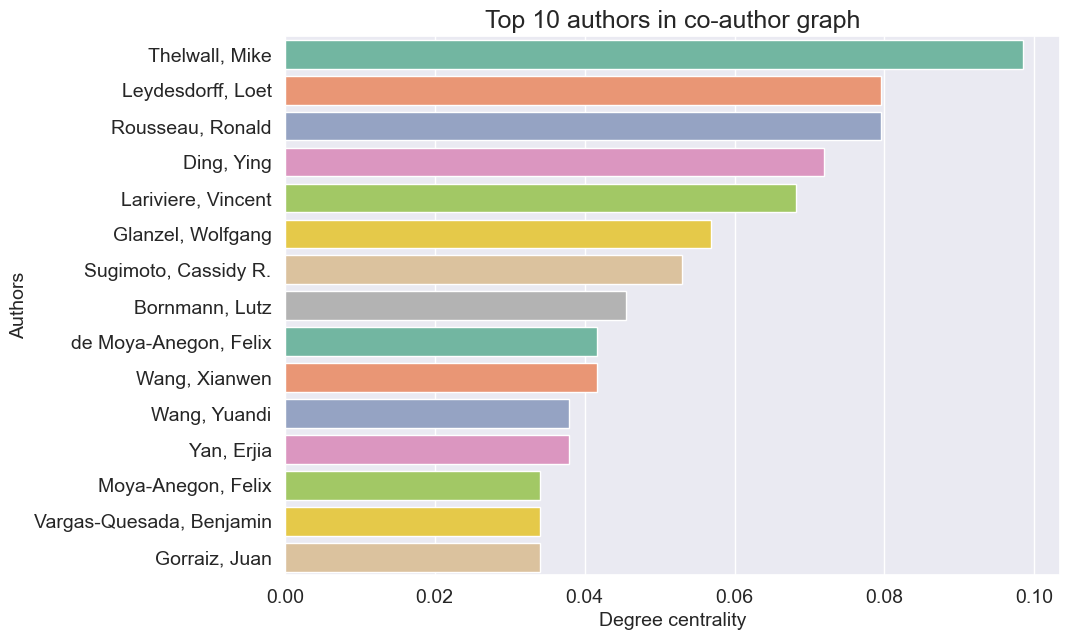

In [73]:
# Visualizing the top 15 co-authors by degree centrality score
sns.set(font_scale=.75)
cent_df_d15 = cent_df.sort_values('degree', ascending = False)[:15]
cent_df_d15.index.name = "author"
cent_df_d15.reset_index(inplace=True)
print()
plt.figure(figsize=(10,7))
ax = sns.barplot(y = "author", x = "degree", data = cent_df_d15, palette = "Set2");
ax.set_alpha(0.8)
ax.set_title("Top 10 authors in co-author graph", fontsize = 18)
ax.set_ylabel("Authors", fontsize=14);
ax.set_xlabel("Degree centrality", fontsize=14);
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)

In [74]:
solo = []
co = []
for i in cent_df_d15["author"]:
    # Calculate solo authorship rate
    so = np.round((len(df[(df['AF'].str.contains(i)) & (df['num-Authors'] == 1)])) / (len(df[df['AF'].str.contains(i)])), decimals = 2)
    solo.append(so)
    # Calculate co-authorship rate
    co.append(1-so)
print(solo, co)



[0.11, 0.17, 0.13, 0.13, 0.02, 0.13, 0.03, 0.17, 0.0, 0.0, 0.0, 0.15, 0.0, 0.0, 0.0] [0.89, 0.83, 0.87, 0.87, 0.98, 0.87, 0.97, 0.83, 1.0, 1.0, 1.0, 0.85, 1.0, 1.0, 1.0]


In [75]:
# Create top 10 authors dataframe
authors = pd.DataFrame(zip(solo, co), columns = ["solo", "coauthor"])
authors["author"] = cent_df_d15["author"]
# Rearrange columns
authors = authors[["author", "solo", "coauthor"]]
authors

,author,solo,coauthor
0,"Thelwall, Mike",0.11,0.89
1,"Leydesdorff, Loet",0.17,0.83
2,"Rousseau, Ronald",0.13,0.87
3,"Ding, Ying",0.13,0.87
4,"Lariviere, Vincent",0.02,0.98
5,"Glanzel, Wolfgang",0.13,0.87
6,"Sugimoto, Cassidy R.",0.03,0.97
7,"Bornmann, Lutz",0.17,0.83
8,"de Moya-Anegon, Felix",0.00,1.00
9,"Wang, Xianwen",0.00,1.00


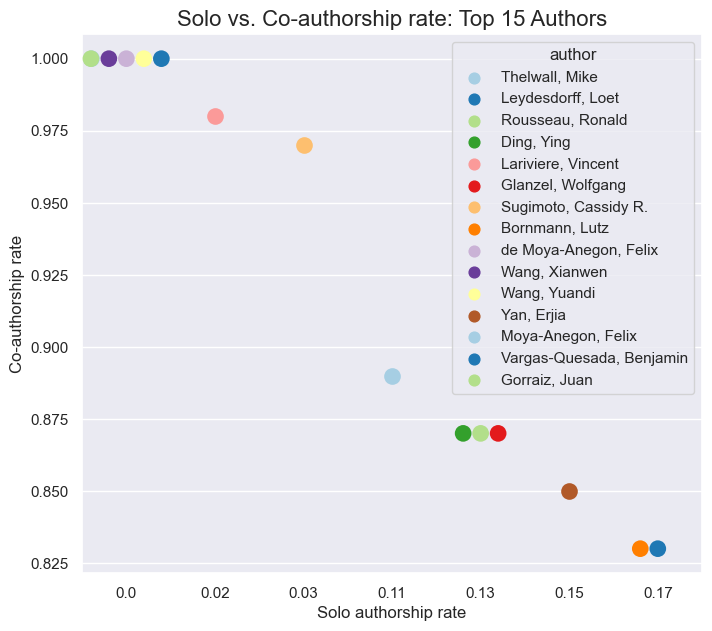

In [76]:
sns.set(rc={'figure.figsize':(8,7)})
fig = sns.swarmplot(x = "solo", y = "coauthor", hue = "author", data = authors, s = 12, palette = "Paired")
plt.title("Solo vs. Co-authorship rate: Top 15 Authors", fontsize = 16)
plt.xlabel("Solo authorship rate")
plt.ylabel("Co-authorship rate")
plt.show()

In [77]:
# Community detection
partition = community.best_partition(giant_coauthor) 
modularity = community.modularity(partition, giant_coauthor)
print("Modularity:", modularity)

Modularity: 0.8405541571153435


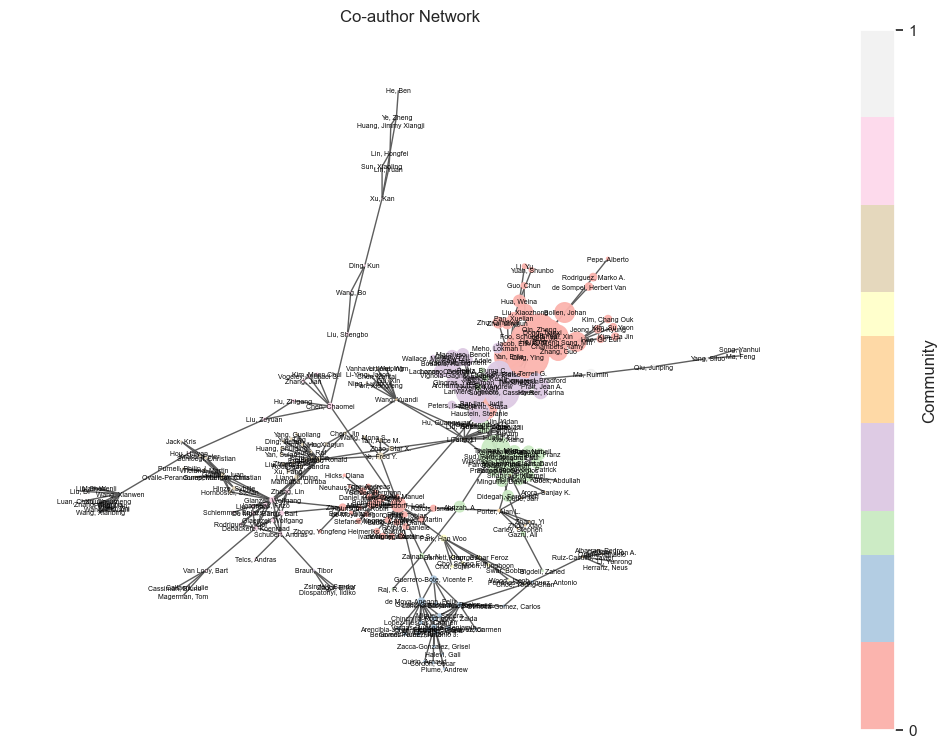

In [78]:
import matplotlib.pyplot as plt
import networkx as nx

# Assuming you've already computed eigenvector centrality and stored it in 'eig'
# and assuming giant_coauthor is your network

# Visualizing the co-author network
plt.figure(figsize=(10, 7))

# Node size based on eigenvector centrality
size = [2000 * eig[node] for node in giant_coauthor]

# Node color based on community membership or some other attribute
# Let's assume 'partition' is a dictionary with node-community mappings
colors = [partition[node] for node in giant_coauthor]

# Create a colormap to map community labels to colors
# Using a light colormap to ensure dark text is readable
cmap = plt.cm.get_cmap('Pastel1', max(partition.values()) + 1)

# Draw the network
nx.draw_spring(
    giant_coauthor, 
    node_size=size, 
    with_labels=True, 
    font_size=5, 
    font_color='black',  # Dark text for better readability
    node_color=colors,  # Node color now based on community membership
    cmap=cmap,  # Apply the light colormap
    edge_color="#555555",  # Changed edge color to a dark grey for better contrast
    alpha=0.95
)

# Display a colorbar to show community color mappings
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])
plt.colorbar(sm, label='Community', ticks=range(max(partition.values()) + 1))

# Display the visualization
plt.title('Co-author Network')
plt.show()



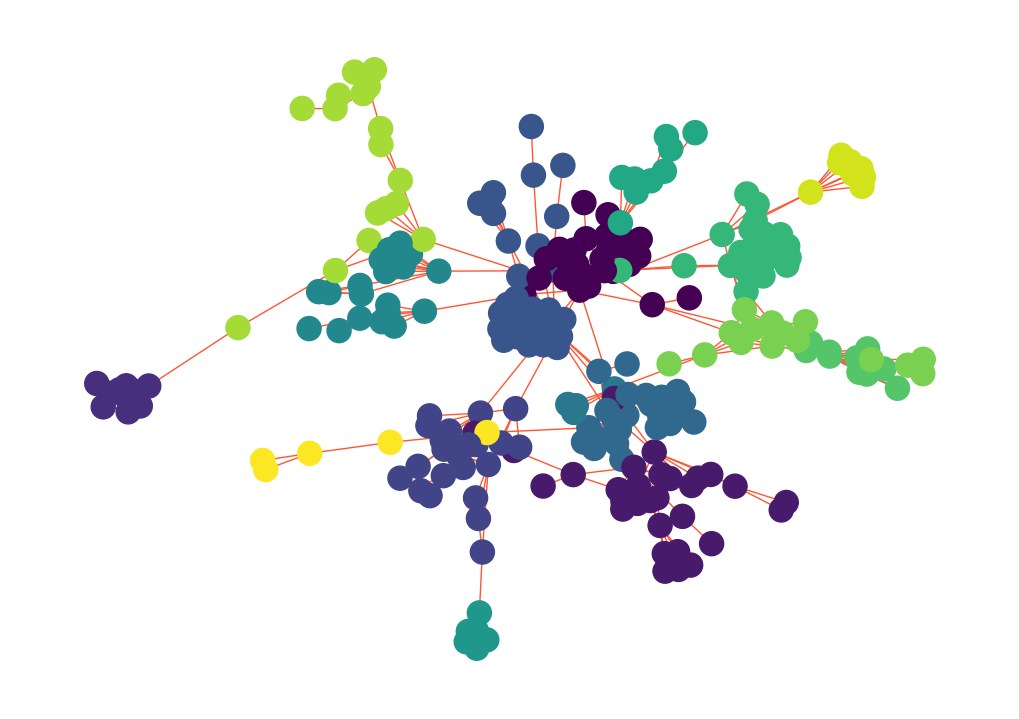

In [79]:
# Visualizing the communities
# Generates a different graph each time
plt.figure(figsize=(10, 7))
colors = [partition[n] for n in giant_coauthor.nodes()]
my_colors = plt.cm.viridis  # Corrected colormap to viridis
nx.draw(giant_coauthor, node_color=colors, cmap=my_colors, edge_color="#FF5733")  # Changed edge color to #FF5733



In [80]:
# Transform the record collection into a format for use with natural language processing applications
data = coll_rec.forNLP("topic_model_data.csv", lower=True, removeNumbers=True, removeNonWords=True, removeWhitespace=True)

# Convert the raw text into a list.
docs = data['abstract']
docs

['the use of the cluster analysis in scientometrics is dealt with the ways of developing citation networks and mapping research field with the help of this method are also presented the methodology of computeraided cluster analysis of citation is described which allows to map the structure of a research field and to identify main tendencies of its development',
 'for a long time rankings overused in evaluating chinese universities research performance the relationship between research production and research quality hasnt been taken seriously in ranking systems most university rankings in china put more weight on research production rather than research quality recently the developmental strategy of chinese universities has shifted from quantity to quality as a result a twodimensional approach was developed in this article to balance quantity and quality the research production index and the research quality index were produced to locate research universities ru from mainland china hon

In [81]:
# Defining a function to clean the text
def clean(docs):
    # Insert function for preprocessing the text
    def sent_to_words(sentences):
        for sentence in sentences:
            yield (simple_preprocess(str(sentence), deacc = True))
    # Tokenize the text
    tokens = sent_to_words(docs)
    # Create stopwords set
    stop = set(stopwords.words("english"))
    # Create lemmatizer
    lemmatiser = WordNetLemmatizer()
    # Remove stopwords from text
    tokens_stopped = [[word for word in post if word not in stop] for post in tokens]
    # Lemmatize text
    tokens_cleaned = [[lemmatiser.lemmatize(word) for word in post] for post in tokens_stopped]
    # Return cleaned text
    return tokens_cleaned

# Cleaning up the raw documents
cleaned_docs = clean(docs)
cleaned_docs

[['use',
  'cluster',
  'analysis',
  'scientometrics',
  'dealt',
  'way',
  'developing',
  'citation',
  'network',
  'mapping',
  'research',
  'field',
  'help',
  'method',
  'also',
  'presented',
  'methodology',
  'computeraided',
  'cluster',
  'analysis',
  'citation',
  'described',
  'allows',
  'map',
  'structure',
  'research',
  'field',
  'identify',
  'main',
  'tendency',
  'development'],
 ['long',
  'time',
  'ranking',
  'overused',
  'evaluating',
  'chinese',
  'university',
  'research',
  'performance',
  'relationship',
  'research',
  'production',
  'research',
  'quality',
  'hasnt',
  'taken',
  'seriously',
  'ranking',
  'system',
  'university',
  'ranking',
  'china',
  'put',
  'weight',
  'research',
  'production',
  'rather',
  'research',
  'quality',
  'recently',
  'developmental',
  'strategy',
  'chinese',
  'university',
  'shifted',
  'quantity',
  'quality',
  'result',
  'twodimensional',
  'approach',
  'developed',
  'article',
  'bala

In [82]:
# Creating a dictionary
id2word = corpora.Dictionary(cleaned_docs)
print(id2word)

Dictionary(21943 unique tokens: ['allows', 'also', 'analysis', 'citation', 'cluster']...)


In [83]:
# Filtering infrequent and over frequent words
id2word.filter_extremes(no_below=15, no_above=0.5)
# Creating a document-term matrix
corpus = [id2word.doc2bow(doc) for doc in cleaned_docs]

In [84]:
# Building an LDA model with 10 topics
model = ldamodel.LdaModel(corpus = corpus,
                          num_topics = 10,
                          id2word = id2word,
                          passes = 10,
                          update_every = 1,
                          chunksize = 1000,
                          per_word_topics = True,
                          random_state = 1)
# Printing the topic-word distributions
pprint(model.print_topics())

[(0,
  '0.050*"research" + 0.029*"analysis" + 0.024*"field" + 0.024*"science" + '
  '0.017*"database" + 0.016*"study" + 0.015*"method" + 0.014*"scientific" + '
  '0.014*"bibliometric" + 0.013*"paper"'),
 (1,
  '0.051*"network" + 0.049*"patent" + 0.021*"technology" + 0.020*"analysis" + '
  '0.015*"technological" + 0.014*"knowledge" + 0.012*"link" + 0.011*"study" + '
  '0.011*"structure" + 0.011*"innovation"'),
 (2,
  '0.021*"method" + 0.016*"retrieval" + 0.015*"query" + 0.015*"document" + '
  '0.013*"approach" + 0.012*"result" + 0.012*"information" + 0.011*"term" + '
  '0.009*"system" + 0.008*"using"'),
 (3,
  '0.064*"citation" + 0.026*"impact" + 0.025*"paper" + 0.020*"journal" + '
  '0.019*"indicator" + 0.017*"number" + 0.015*"publication" + 0.015*"author" + '
  '0.013*"factor" + 0.013*"index"'),
 (4,
  '0.044*"user" + 0.033*"web" + 0.029*"search" + 0.027*"information" + '
  '0.018*"study" + 0.014*"online" + 0.013*"task" + 0.012*"site" + '
  '0.011*"image" + 0.011*"result"'),
 (5,
  '0

In [85]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(model, corpus, id2word, mds = "tsne")
vis

PreparedData(topic_coordinates=                x           y  topics  cluster       Freq
topic                                                    
9     -100.617798   31.028980       1        1  16.916623
3       67.106041    8.516604       2        1  13.715927
8       45.521023  -80.931885       3        1  12.109336
2      156.721313  -32.345150       4        1  11.686798
5        0.054247   88.810188       5        1  10.286559
0      -82.205734  -92.854057       6        1   8.445600
4      122.110527 -137.035126       7        1   7.699725
1      119.028221   85.994873       8        1   6.939825
6        0.013198 -164.709488       9        1   6.216972
7      -20.935684  -17.659830      10        1   5.982634, topic_info=            Term         Freq        Total Category  logprob  loglift
91       journal  5137.000000  5137.000000  Default  30.0000  30.0000
3       citation  5860.000000  5860.000000  Default  29.0000  29.0000
19      research  7873.000000  7873.000000  Default  28.0000  28.0000
101      science  5024.000000  5024.000000  Default  27.0000  27.0000
17       network  1938.000000  1938.000000  Default  26.0000  26.0000
..           ...          ...          ...      ...      ...      ...
126       impact   222.674032  2823.483365  Topic10  -4.9952   0.2763
106        study   216.359186  5420.084856  Topic10  -5.0240  -0.4046
876    education   146.843638   323.348836  Topic10  -5.4115   2.0269
509         work   161.106752  1124.740034  Topic10  -5.3188   0.8731
229  publication   171.444903  3587.479621  Topic10  -5.2567  -0.2246

[723 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
2488      8  0.987158       aca
533       1  0.033647  academic
533       2  0.029569  academic
533       3  0.109098  academic
533       5  0.064235  academic
...     ...       ...       ...
108       5  0.430737      year
108       6  0.075765      year
108       7  0.002105      year
108      10  0.007717      year
3201      5  0.977954    yearly

[1645 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 4, 9, 3, 6, 1, 5, 2, 7, 8])